In [1]:
import matplotlib.pyplot as plt
from src.process_data import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import MultipleLocator

In [2]:
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 2

df_all = pd.read_csv(f"../Data/{type_perc}_percolation/all_data_{dim}D.dat", sep='\t')
df_all

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,...,pt_erro,nt_mean,nt_erro,perc_rate,perc_ci_low,perc_ci_high,pt_mean_uncond,pt_erro_uncond,nt_mean_uncond,nt_erro_uncond
0,bond,3,2,2000,200,0.0001,0.003,0.4,1,22,...,0.0028163148218908,194.3612646286452,1.1795640335640498,0.227273,1.012289e-01,0.434404,0.206448,0.081162,44.173015,17.367484
1,bond,3,2,2000,200,0.0001,0.003,0.4,2,22,...,Null,Null,Null,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
2,bond,3,2,2000,200,0.0001,0.003,0.4,3,22,...,Null,Null,Null,0.000000,1.387779e-17,0.148660,0.000000,0.000000,0.000000,0.000000
3,bond,3,2,2000,200,0.0001,0.003,0.5,1,20,...,0.0026084823837827,191.88792206829456,2.0292766851928925,1.000000,8.388699e-01,1.000000,0.916450,0.002608,191.887922,2.029277
4,bond,3,2,2000,200,0.0001,0.003,0.5,2,20,...,0.0014783806273907,192.42416783378337,2.841732837035604,0.600000,3.865779e-01,0.781196,0.549305,0.100293,115.454501,21.147858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,bond,3,2,2000,200,0.0001,0.330,0.8,2,20,...,Null,Null,Null,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
296,bond,3,2,2000,200,0.0001,0.330,0.8,3,20,...,Null,Null,Null,0.000000,0.000000e+00,0.161130,0.000000,0.000000,0.000000,0.000000
297,bond,3,2,2000,200,0.0001,0.330,1.0,1,100,...,Null,Null,Null,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000
298,bond,3,2,2000,200,0.0001,0.330,1.0,2,100,...,Null,Null,Null,0.000000,0.000000e+00,0.036995,0.000000,0.000000,0.000000,0.000000


In [ ]:
df_clean = df_all[df_all[["pt_mean", "nt_mean"]].notna().all(axis=1)]
df_clean.loc[:, "rho":"nt_erro"].sort_values(by=["rho", "p0"])

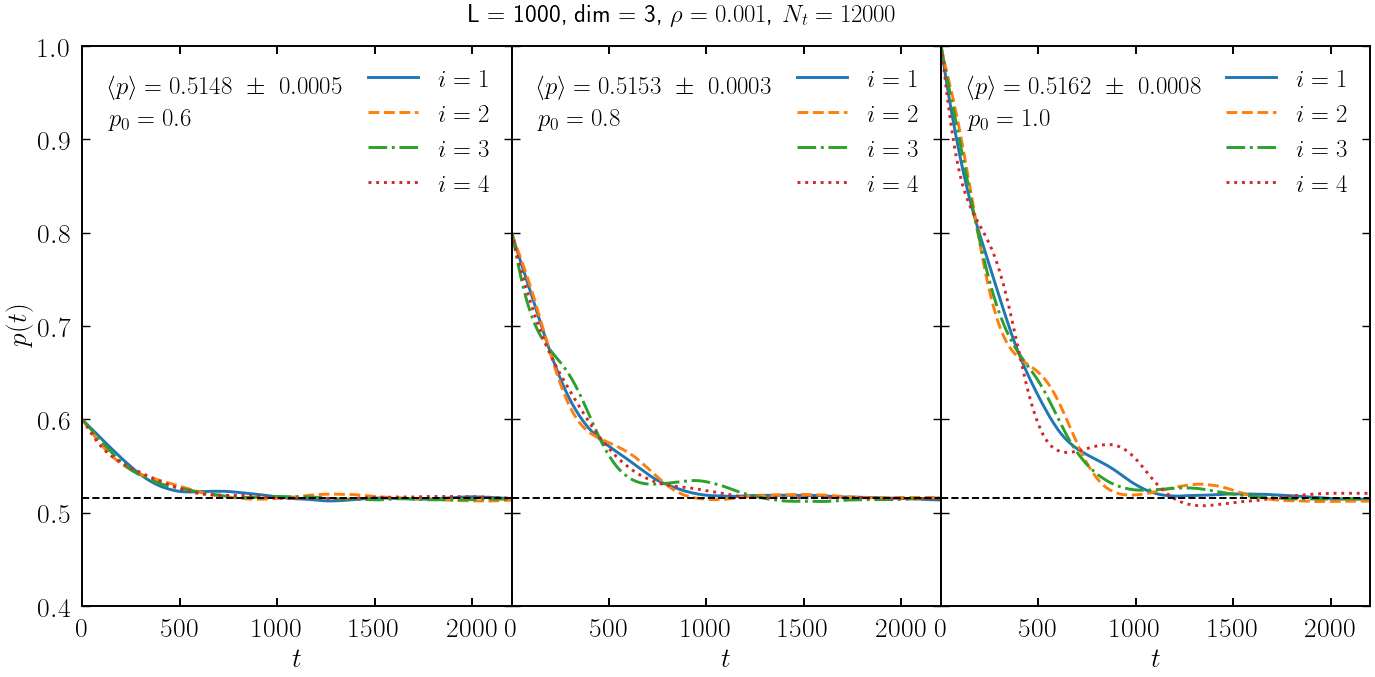

Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):
p0=0.6 | n_curves=4 | mean=0.514842 ± 0.000521 (IC95%: 0.513867–0.515817)
p0=0.8 | n_curves=4 | mean=0.515304 ± 0.000313 (IC95%: 0.514718–0.515890)
p0=1.0 | n_curves=4 | mean=0.516171 ± 0.000842 (IC95%: 0.514601–0.517675)


In [ ]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0_lst = [0.6, 0.8, 1.0]
seed_name = [14574188, 344587444, 198323458]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharex=True, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(12345)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"p_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    ax.set_ylim([0.4, 1.0])

    means_per_curve = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"p_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve.append(mi)

    mean_pt, se_pt, (lo_pt, hi_pt) = bootstrap_mean_scalar(means_per_curve,prop='pt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_pt, "se": se_pt, "lo": lo_pt, "hi": hi_pt, "n_used": len(means_per_curve)})
    count += mean_pt
    ax.legend(fontsize=18)
    #ax.set_title(fr"$p_0={p0:.1f}$", fontsize=18)
    txt1 = fmt_pm(mean_pt, se_pt, len(means_per_curve), dec=4)   # usa "<1e-3" se for minúsculo
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo

axes[0].set_ylabel(r"$p(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# ---------- resumo no console ----------
print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
for r in results:
    print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
          f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

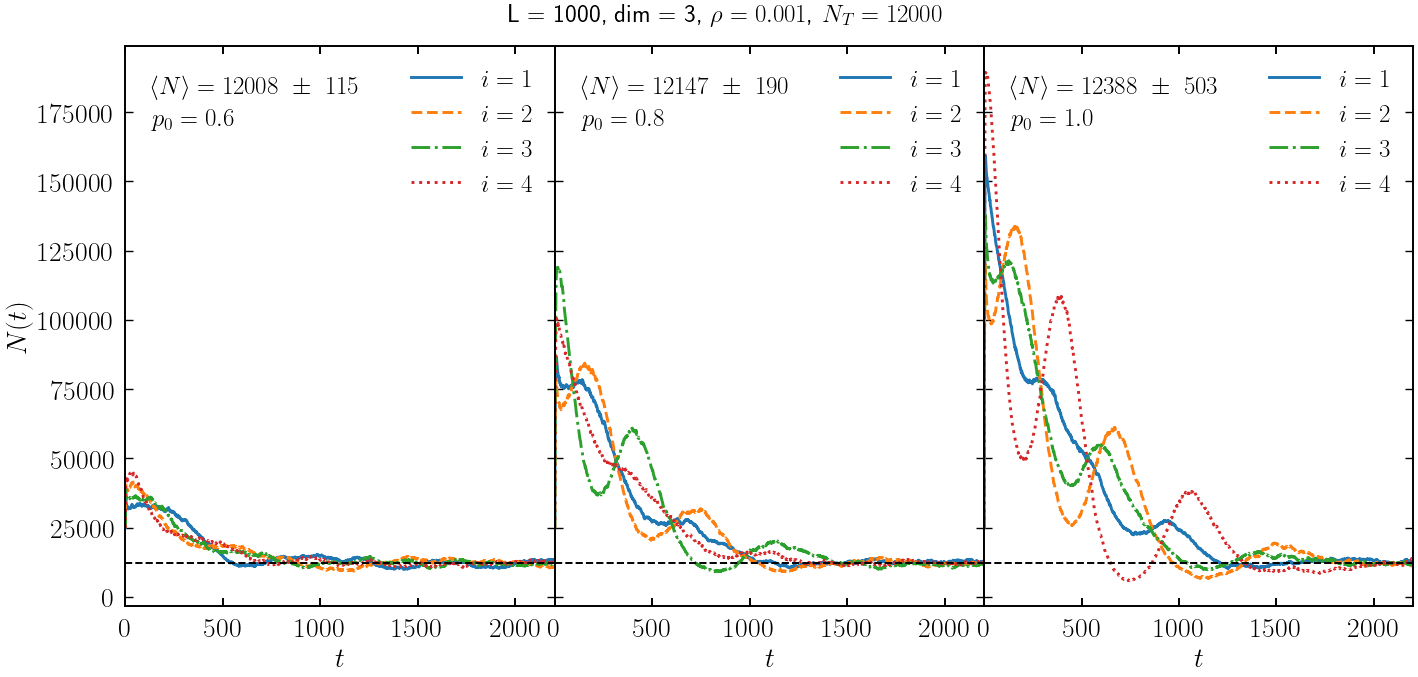

In [16]:
# ---------- seus parâmetros ----------
type_perc = "bond"
num_colors = 4
dim = 3
L = 1000
NT = 12000
k=1.0e-08
rho=1.0e-03
p0_lst = [0.6, 0.8, 1.0]
seed_name = [14574188, 344587444, 198323458]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95

# ---------- plot + bootstrap ----------
fig, axes = plt.subplots(
    1, 3, sharex=True, sharey=True, figsize=(14,7),
    gridspec_kw={'wspace': 0, 'hspace': 0}  # cola os subplots
)

results = []
rng = np.random.default_rng(54321)

count = 0
linestyles = ['solid', 'dashed', 'dashdot', "dotted", 'None']
#linestyles = ['solid', 'solid', 'solid', 'solid']
for index, ax in enumerate(axes):
    p0 = p0_lst[index]
    data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed_name[index])
    
    for i in range(1, num_colors+1):
        ax.plot(data["t"], data[f"N_{i}"], ls=linestyles[i-1], label=f"$i = {i}$", linewidth=1.5*thickness)

    ax.set_xlabel("$t$")
    ax.xaxis.set_major_locator(MultipleLocator(500))
    ax.set_xlim([0, max(data["t"])])
    #ax.set_ylim([0.4, 1.0])

    means_per_curve_Nt = []
    for i in range(1, num_colors+1):
        mi = tail_mean(data[f"N_{i}"], tail_frac=tail_frac)
        if np.isfinite(mi):
            means_per_curve_Nt.append(mi)

    mean_Nt, se_Nt, (lo_Nt, hi_Nt) = bootstrap_mean_scalar(means_per_curve_Nt, prop='Nt' ,n_boot=n_boot, ci=ci, rng=rng)
    results.append({"p0": p0, "mean": mean_Nt, "se": se_Nt, "lo": lo_Nt, "hi": hi_Nt, "n_used": len(means_per_curve_Nt)})
    count += mean_Nt
    ax.legend(fontsize=18)
    
    txt1 = fmt_pm_N(mean_Nt, se_Nt, n_used=len(means_per_curve_Nt), dec=0)  # ajuste dec se quiser
    txt2 = rf"$p_0 = {p0:.1f}$"
    ax.text(0.06, 0.95, txt1, transform=ax.transAxes, ha="left", va="top", fontsize=18)
    ax.text(0.06, 0.89, txt2, transform=ax.transAxes, ha="left", va="top", fontsize=18)

for ax in axes:
    ax.axhline(y=count/3, xmin=0, xmax=1.0, color='k', ls='--', lw=thickness)  # xmin/xmax em fração do eixo

axes[0].set_ylabel(r"$N(t)$")
# tira rótulos de y dos painéis internos para ficar limpo/colado
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# margens externas (não afetam o espaçamento entre subplots)
fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $N_T = {NT}$",
             fontsize=18, fontweight="bold", y=0.96)
fig.subplots_adjust(left=0.07, right=0.99, top=0.90, bottom=0.10)

plt.show()

# # ---------- resumo no console ----------
# print("Resumo por subplot (média de p(t) na cauda + erro bootstrap entre as 4 curvas):")
# for r in results:
#     print(f"p0={r['p0']:.1f} | n_curves={r['n_used']} | "
#           f"mean={r['mean']:.6f} ± {r['se']:.6f} (IC{int(ci*100)}%: {r['lo']:.6f}–{r['hi']:.6f})")

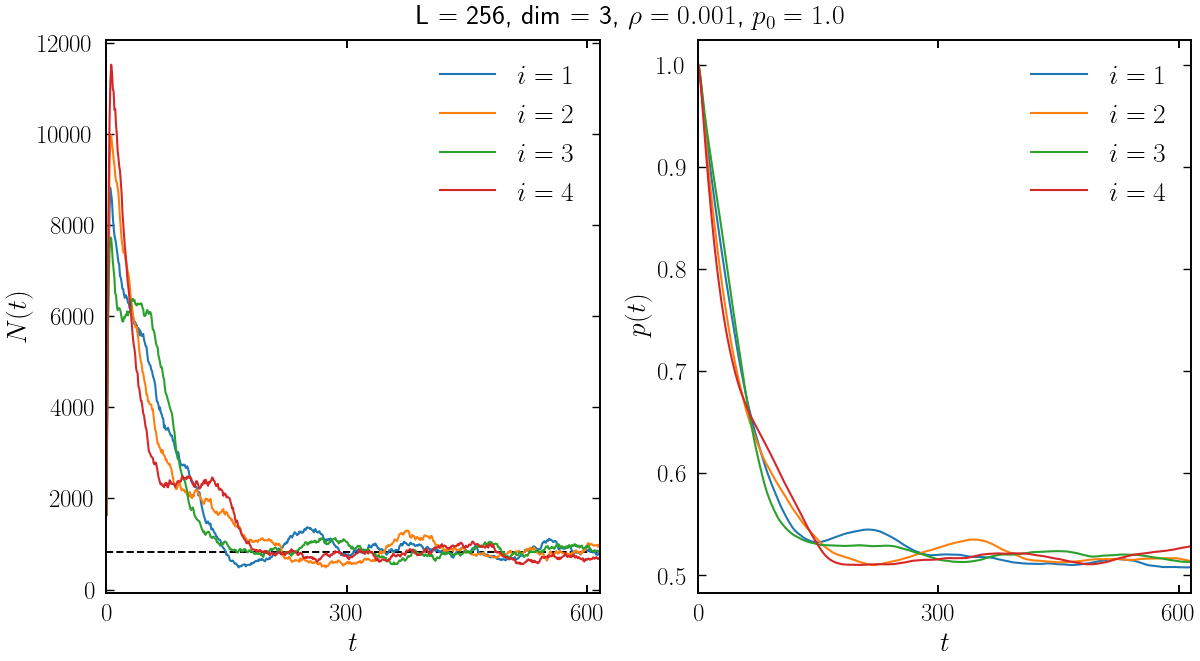

In [15]:
type_perc = "bond"
num_colors = 4
dim = 3
L = 256
NT = 820
k=1.0e-06
rho=1.0e-03
p0 = 1.00
seed = 1055002752
#seed = 665884593

data = data_single_sample(type_perc, num_colors, dim, L, NT, k, rho, p0, seed)

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
fontsize_ticks = 13
thickness = 1.4

fig, axes = plt.subplots(1,2, figsize=(14,7))

handles, labels = [], []
for index, ax in enumerate(axes):
    if index == 1:
        prop = "p"
        label_y = r"$p(t)$"
        
    else:
        prop = "N"
        label_y = r"$N(t)$"
        ax.axhline(y=NT, xmin=min(data["t"]), xmax=max(data["t"]), linewidth=thickness, color='k', ls="dashed", label="_nolegend_")
    for i in range(1,5):
        ax.plot(data["t"], data[f"{prop}_{i}"], '-', label=f"$i = {i}$")
    
    ax.legend(fontsize=20)
    ax.set_ylabel(label_y)
    ax.set_xlim([min(data["t"]), max(data["t"])])
    ax.set_xlabel("$t$")
    
    for ax in axes.ravel():
        ax.xaxis.set_major_locator(MultipleLocator(300))
        ax.tick_params(axis="both", which="major", labelsize=18)

fig.suptitle(f"L = {L}, dim = {dim},  $\\rho = {rho}$, $p_0 = {p0}$", fontsize=20, fontweight="bold", y=0.95)  # título comum
fig.subplots_adjust(top=0.90)  # abre espaço no topo para o título

plt.show()